In [1]:
import numpy as np
import core as phgen
import matplotlib.pyplot as plt

In [2]:
act_vol, ctac_vol, mask_bin_dict = phgen.create_nema(
    matrix_size=(128,128,128),
    voxel_size_mm=(4.42,4.42,4.42),
    nema_dict=phgen.earl_nema_dict,
    supersample=4
)

In [3]:
phgen.earl_nema_dict

{'mu_values': {'perspex_mu_value': 0.15,
  'fill_mu_value': 0.14,
  'lung_mu_value': 0.043},
 'activity_concentration_background': 0.0,
 'include_lung_insert': False,
 'sphere_dict': {'ring_R': 57,
  'ring_z': -37,
  'spheres': {'diametre_mm': [13, 17, 22, 28, 37, 60],
   'angle_loc': [270, 150, 30, 90, 330, 210],
   'act_conc_MBq_ml': [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]}}}

In [6]:
earl_sphere_dict = phgen.earl_nema_dict["sphere_dict"]["spheres"]

for i in range(1,7):
    est_bin_act = np.sum(act_vol * mask_bin_dict[f"sphere_{i}"])
    r_mm = earl_sphere_dict["diametre_mm"][i-1] / 2
    tru_act = earl_sphere_dict["act_conc_MBq_ml"][i-1] * 1e-3 * 4 / 3 * np.pi * r_mm**3
    print(f"RC bin (sphere_{i}) = {est_bin_act/tru_act:.3f}")

RC bin (sphere_1) = 0.992
RC bin (sphere_2) = 1.003
RC bin (sphere_3) = 0.999
RC bin (sphere_4) = 1.002
RC bin (sphere_5) = 1.000
RC bin (sphere_6) = 1.000


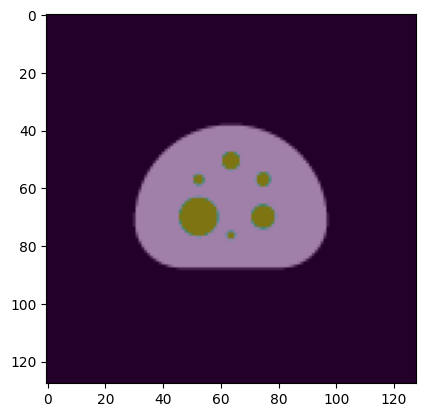

In [30]:
plt.imshow(act_vol[55,:,:])
plt.imshow(mask_frac_dict["background"][55,:,:], alpha=0.5, cmap="gray")

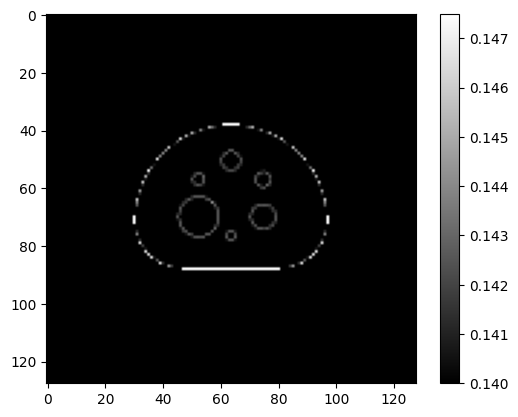

In [24]:
plt.imshow(ctac_vol[55,:,:], cmap="gray", vmin = 0.14)
plt.colorbar()

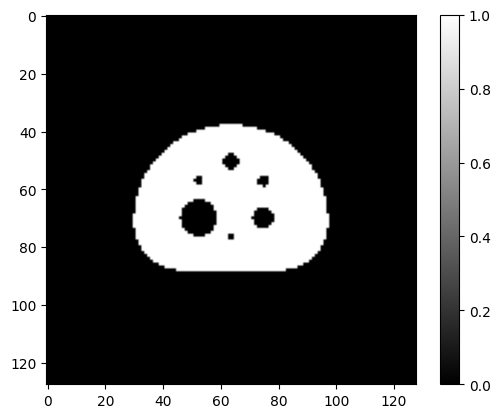

In [25]:
plt.imshow(mask_bin_dict["background"][55,:,:], cmap="gray")
plt.colorbar()

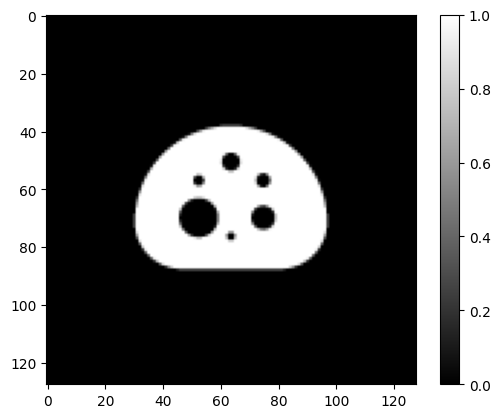

In [26]:
plt.imshow(mask_frac_dict["background"][55,:,:], cmap="gray")
plt.colorbar()